# ViT Video Food Classifier -- Google Colab Notebook

Fine-grained 16-class food classification using MobileViT-XXS / ViT-B + BiLSTM.

**Run order:** clone -> mount drive -> install -> env check -> data download -> upload to HF -> train -> evaluate -> export -> upload model

## 1. Setup -- Clone & Install

In [ ]:
# --- 1. Clone repo & make vit_video importable --------------------------
import os, sys, subprocess

REPO_URL = "https://github.com/whispr-messenger/moderation-service.git"
REPO_DIR = "/content/moderation-service"
BRANCH   = "WHISPR-668"
SRC_DIR  = os.path.join(REPO_DIR, "src")
VIT_DIR  = os.path.join(SRC_DIR, "vit_video")

os.chdir("/content")

def _run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    return r.returncode, (r.stdout or "") + (r.stderr or "")

need_clone = not os.path.isfile(os.path.join(VIT_DIR, "__init__.py"))
if need_clone:
    if os.path.exists(REPO_DIR):
        subprocess.run(["rm", "-rf", REPO_DIR], check=False)
    rc, out = _run(["git", "clone", "-b", BRANCH, "--depth", "1", REPO_URL, REPO_DIR])
    if rc != 0:
        print("Branch clone failed, falling back to main...")
        subprocess.run(["rm", "-rf", REPO_DIR], check=False)
        rc, out = _run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR])
        if rc != 0:
            raise RuntimeError("git clone failed:\n" + out)
    print("Cloned into", REPO_DIR)
else:
    print("Repo already present at", REPO_DIR)

assert os.path.isfile(os.path.join(VIT_DIR, "__init__.py")), \
    "vit_video/__init__.py not found under " + VIT_DIR

# Put SRC_DIR at the very front of sys.path and drop any stale cached module
if SRC_DIR in sys.path:
    sys.path.remove(SRC_DIR)
sys.path.insert(0, SRC_DIR)
for m in [k for k in list(sys.modules) if k == "vit_video" or k.startswith("vit_video.")]:
    del sys.modules[m]

os.chdir(VIT_DIR)
import vit_video
print("OK: vit_video loaded from", vit_video.__file__)
print("cwd =", os.getcwd())


Repo already present at /content/moderation-service
OK: vit_video loaded from /content/moderation-service/src/vit_video/__init__.py
cwd = /content/moderation-service/src/vit_video


In [ ]:
# Mount Google Drive (optional - for checkpoint persistence)
# Skip this cell if you don't want Drive sync.
DRIVE_CHECKPOINT_DIR = None
DRIVE_CHECKPOINT_PATH = None

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/whispr-checkpoints'
    os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
    DRIVE_CHECKPOINT_PATH = os.path.join(DRIVE_CHECKPOINT_DIR, 'best_food_classifier.pth')
    print(f'Drive checkpoint dir: {DRIVE_CHECKPOINT_DIR}')
    if os.path.exists(DRIVE_CHECKPOINT_PATH):
        print(f'Found existing checkpoint: {DRIVE_CHECKPOINT_PATH}')
    else:
        print('No existing checkpoint -- training will start from scratch')
except Exception as e:
    print(f'Drive not mounted ({e}) -- training will work but no checkpoint sync')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive checkpoint dir: /content/drive/MyDrive/whispr-checkpoints
Found existing checkpoint: /content/drive/MyDrive/whispr-checkpoints/best_food_classifier.pth


In [ ]:
# Install dependencies
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'icrawler', 'huggingface_hub'], check=True)
print('Dependencies installed')

Dependencies installed


## 2. Environment Check

In [ ]:
import importlib
from pathlib import Path

print(f'Python {sys.version}')
print()
for pkg in ['torch', 'torchvision', 'timm', 'cv2', 'sklearn', 'icrawler', 'huggingface_hub']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:18s} {getattr(m, "__version__", "ok")}')
    except ImportError:
        print(f'  {pkg:18s} NOT INSTALLED')

import torch
print(f'\nCUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

from vit_video.utils.hardware import get_device, print_device_info
device = get_device()
print_device_info(hint_cuda=True)

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

  torch              2.10.0+cpu
  torchvision        0.25.0+cpu
  timm               1.0.26
  cv2                4.13.0
  sklearn            1.6.1
  icrawler           0.6.10
  huggingface_hub    1.8.0

CUDA available: False
Device: cpu  (CUDA: False)
Tip: CUDA build — pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124


## 3. HuggingFace Authentication

Add `HF_TOKEN` to **Colab Secrets** (key icon in the left sidebar) for upload/private dataset access.
Public dataset download works without a token.

In [ ]:
# --- 3. HuggingFace token (Colab Secrets > env > cached file > prompt) ---
import os
from pathlib import Path

HF_TOKEN = ""
TOKEN_CACHE = Path("/content/.hf_token")  # persists across cell re-runs

# 1) Colab Secrets (recommended: left key icon, add key "HF_TOKEN")
try:
    from google.colab import userdata
    HF_TOKEN = (userdata.get("HF_TOKEN") or "").strip()
    if HF_TOKEN: print("HF_TOKEN loaded from Colab Secrets")
except Exception:
    pass

# 2) env var
if not HF_TOKEN:
    HF_TOKEN = os.environ.get("HF_TOKEN", "").strip()
    if HF_TOKEN: print("HF_TOKEN loaded from environment")

# 3) cached file
if not HF_TOKEN and TOKEN_CACHE.exists():
    HF_TOKEN = TOKEN_CACHE.read_text().strip()
    if HF_TOKEN: print(f"HF_TOKEN loaded from {TOKEN_CACHE}")

# 4) interactive prompt -- paste once, cached for rest of session
if not HF_TOKEN:
    try:
        from getpass import getpass
        HF_TOKEN = getpass("Paste HF token (hf_...), or Enter to skip: ").strip()
    except Exception:
        HF_TOKEN = ""

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    try:
        TOKEN_CACHE.write_text(HF_TOKEN)
        TOKEN_CACHE.chmod(0o600)
    except Exception: pass
    try:
        from huggingface_hub import login
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("huggingface_hub login: OK")
    except Exception as e:
        print(f"huggingface_hub login warning: {e}")
else:
    print("No HF_TOKEN -- public downloads still work; uploads will be skipped")


HF_TOKEN loaded from Colab Secrets


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


huggingface_hub login: OK


## 4. Data -- Categories & Paths

In [ ]:
# --- 4. Paths + 16-class category dictionary ----------------------------
from vit_video.paths import DEFAULT_DATASET_DIR, DEFAULT_FRAMES_DIR, PACKAGE_ROOT
from vit_video.data.splits import frames_directory_has_images, count_frame_images

DATASET_DIR = DEFAULT_DATASET_DIR
FRAMES_DIR  = DEFAULT_FRAMES_DIR
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

HEALTH_LABELS = {
    "fruits":"healthy","vegetables":"healthy","salads":"healthy","seafood":"healthy",
    "grilled_meat":"healthy","grain_bowls":"healthy","soups":"healthy","smoothies":"healthy",
    "burgers":"unhealthy","pizza":"unhealthy","fried_food":"unhealthy","desserts":"unhealthy",
    "candy_sweets":"unhealthy","salty_snacks":"unhealthy","sugary_drinks":"unhealthy",
    "not_food":"not_food",
}

FOOD_CATEGORIES = {
    "fruits": ["banana fruit","apple fruit","orange citrus","mixed berries","mango sliced",
               "watermelon slice","kiwi halved","pineapple sliced","grapes bunch","pomegranate",
               "papaya sliced","blueberries","strawberries","peach sliced","pear green",
               "cherry bowl","plum purple","cantaloupe","passion fruit","dragon fruit",
               "fig fresh","apricot","raspberry","tangerine","coconut","grapefruit","avocado"],
    "vegetables": ["broccoli steamed","roasted vegetables","vegetable stir fry","grilled zucchini",
                   "sauteed mushrooms","asparagus grilled","bell pepper sliced","cauliflower roasted",
                   "brussels sprouts","spinach sauteed","green beans","sweet corn cob","eggplant grilled",
                   "artichoke cooked","beets roasted","carrots roasted","cabbage sauteed","kale cooked",
                   "peas green","radish salad","turnip roasted","celery sticks","bok choy",
                   "snap peas","okra cooked","leek sliced","pumpkin roasted"],
    "salads": ["green salad bowl","caesar salad","mixed greens salad","greek salad feta",
               "caprese salad","quinoa salad","cobb salad","arugula salad","tabbouleh",
               "pasta salad","coleslaw","beet goat cheese salad","chickpea salad","nicoise salad",
               "fruit salad","potato salad","southwest salad","thai mango salad","seaweed salad",
               "fattoush salad","spinach strawberry salad","broccoli salad","lentil salad warm",
               "asian sesame salad","waldorf salad","kale spinach salad","cucumber tomato salad"],
    "seafood": ["grilled salmon","sushi roll","baked cod","grilled shrimp","poke bowl tuna",
                "sashimi platter","fish tacos","steamed mussels","lobster tail grilled","scallops seared",
                "grilled tuna steak","shrimp cocktail","crab legs steamed","oysters fresh","calamari grilled",
                "tilapia baked","ceviche fresh","smoked salmon bagel","sardines grilled","sea bass baked",
                "trout pan seared","clam chowder","fish curry","prawn stir fry","mackerel grilled",
                "octopus grilled","anchovy plate"],
    "grilled_meat": ["grilled chicken breast","turkey breast sliced","hard boiled eggs","grilled steak",
                     "lamb chops grilled","pork tenderloin roasted","chicken kebab","beef stir fry",
                     "rotisserie chicken","turkey meatballs","chicken thighs grilled","sirloin steak",
                     "venison steak","duck breast seared","beef brisket smoked","baked chicken wings",
                     "pork chops grilled","flank steak","rabbit roasted","quail grilled",
                     "beef jerky","chicken satay","shawarma chicken","pulled pork",
                     "filet mignon","rack of lamb","beef tartare"],
    "grain_bowls": ["quinoa bowl","brown rice bowl","chickpea buddha bowl","overnight oats",
                    "oatmeal breakfast","whole grain toast avocado","granola yogurt","couscous bowl",
                    "farro grain bowl","barley soup","acai bowl","chia pudding",
                    "rice cakes","cottage cheese bowl","tofu rice bowl","black bean rice bowl",
                    "burrito bowl","bibimbap","risotto mushroom","congee","polenta creamy",
                    "muesli bowl","bulgur wheat bowl","wild rice pilaf","tabbouleh grain","hummus bowl",
                    "poke rice bowl"],
    "soups": ["lentil soup","miso soup","vegetable soup","minestrone","tomato soup",
              "chicken noodle soup","butternut squash soup","gazpacho","pho noodle soup","wonton soup",
              "corn chowder","mushroom soup","black bean soup","split pea soup","french onion soup",
              "egg drop soup","coconut curry soup","borscht","hot and sour soup","ramen soup",
              "tortilla soup","broccoli cheddar soup","lobster bisque","pozole","laksa",
              "udon soup","bone broth"],
    "smoothies": ["green smoothie","berry smoothie","mango smoothie","banana smoothie",
                  "protein smoothie","acai smoothie","spinach smoothie","strawberry banana smoothie",
                  "peanut butter smoothie","avocado smoothie","coconut smoothie","blueberry smoothie",
                  "oat milk smoothie","detox green juice","carrot orange juice","beet juice",
                  "watermelon juice","celery juice","ginger turmeric shot","matcha latte",
                  "kombucha","fresh orange juice","cucumber mint water","lemon water",
                  "iced green tea","coconut water","almond milk smoothie"],
    "burgers": ["cheeseburger","bacon cheeseburger","double cheeseburger","big mac","slider burger",
                "mushroom swiss burger","bbq bacon burger","wagyu burger","turkey burger",
                "veggie burger","patty melt","western burger","jalapeno burger","blue cheese burger",
                "smash burger","whopper burger","breakfast burger","truffle burger","chipotle burger",
                "teriyaki burger","elk burger","bison burger","lamb burger","hot dog bun",
                "gourmet burger","fast food burger","in n out burger"],
    "pizza": ["pepperoni pizza","margherita pizza","meat lovers pizza","hawaiian pizza",
              "deep dish pizza","thin crust pizza","stuffed crust pizza","buffalo chicken pizza",
              "bbq chicken pizza","white pizza","supreme pizza","four cheese pizza",
              "mushroom pizza","veggie pizza","calzone","pizza rolls","flatbread pizza",
              "sicilian pizza","detroit pizza","neapolitan pizza","french bread pizza",
              "bagel bites","pizza hut box","dominos pizza","frozen pizza","garlic knots","pizza dough"],
    "fried_food": ["french fries","fried chicken bucket","chicken wings deep fried","onion rings",
                   "mozzarella sticks","corn dog","fish and chips","chicken nuggets",
                   "fried calamari","tempura shrimp","jalapeno poppers","fried oreos",
                   "fried pickles","fried cheese curds","chicken tenders","fried wontons",
                   "hush puppies","fried zucchini","corn fritters","fried shrimp basket",
                   "tater tots","fried ravioli","poutine","loaded fries","curly fries",
                   "waffle fries","sweet potato fries"],
    "desserts": ["chocolate cake","glazed donut","cupcake frosting","cheesecake slice",
                 "churros","cinnamon roll","brownie chocolate","pancakes syrup",
                 "funnel cake","cream puff","tiramisu","pie slice cream",
                 "waffle chocolate","eclair pastry","croissant pastry","baklava",
                 "apple pie","red velvet cake","birthday cake","creme brulee",
                 "panna cotta","profiteroles","danish pastry","scone clotted cream",
                 "tres leches cake","bread pudding","glazed donuts box"],
    "candy_sweets": ["candy unwrapping","chocolate bar","gummy bears","jelly beans",
                     "cotton candy","caramel popcorn","lollipop","ice cream sundae",
                     "ice cream cone","frozen yogurt","popsicle","milkshake thick",
                     "chocolate truffles","fudge squares","marshmallow smores","toffee candy",
                     "taffy pulled","rock candy","candy corn","licorice candy",
                     "chocolate mousse","m and m candy","skittles candy","kit kat",
                     "snickers bar","reeses peanut butter cup","gummy worms"],
    "salty_snacks": ["potato chips","nachos cheese","cheese puffs","pretzel bites",
                     "corn chips salsa","popcorn buttered","trail mix","crackers cheese",
                     "doritos chips","cheetos bag","pringles can","tortilla chips",
                     "goldfish crackers","chex mix","beef jerky snack","pork rinds",
                     "sunflower seeds","mixed nuts salted","rice crackers","cheese crackers",
                     "onion dip chips","hummus chips","breadsticks","cheese balls",
                     "bugles cone","funyuns","combos pretzel"],
    "sugary_drinks": ["cola pouring glass","milkshake straw","energy drink can","iced frappuccino",
                      "bubble tea boba","slurpee frozen","lemonade pitcher","sweet iced tea",
                      "hot chocolate whipped cream","mocha sweet cream","fruit punch bowl","capri sun",
                      "kool aid pitcher","mountain dew soda","sprite soda","fanta orange",
                      "root beer float","cream soda","dr pepper soda","gatorade bottle",
                      "arizona iced tea","starbucks frappuccino","chocolate milk","strawberry milkshake",
                      "vanilla milkshake","mango lassi","pina colada"],
    "not_food": ["cat sleeping couch","dog playing park","bird flying sky","horse field",
                 "fish aquarium","rabbit pet","person walking street","people jogging",
                 "crowd concert","children playground","office workers meeting","students classroom",
                 "car driving highway","bicycle path","airplane sky","train station",
                 "sunset ocean beach","mountain hiking","flowers garden","snow forest",
                 "waterfall tropical","desert sand dunes","city skyline night","construction crane",
                 "shopping mall","bridge architecture","book library","laptop desk work",
                 "guitar music","painting art museum","phone texting","camera lens",
                 "soccer ball field","basketball court","swimming pool","yoga mat",
                 "empty plate","kitchen counter","cutting board","cooking pot",
                 "grocery aisle","restaurant empty tables","menu card","vending machine",
                 "kitchen utensils","oven appliance","refrigerator open","coffee machine",
                 "wine glasses empty","barbeque grill empty","dining table no food"],
}

NON_FOOD_CLASSES = {"not_food"}
assert set(FOOD_CATEGORIES) == set(HEALTH_LABELS), "Category set mismatch"
print(f"Dataset dir: {DATASET_DIR}")
print(f"Frames dir:  {FRAMES_DIR}")
print(f"Classes: {len(FOOD_CATEGORIES)}  (frames on disk: {count_frame_images(FRAMES_DIR)})")


Dataset dir: /content/moderation-service/src/vit_video/food_data
Frames dir:  /content/moderation-service/src/vit_video/food_data/frames
Classes: 16  (frames on disk: 0)


## 5. Dataset Download

**Option A:** Download from HuggingFace (fast, ~30s).  
**Option B:** Scrape from Bing if HF download fails or repo is empty (~30 min).

In [ ]:
HF_DATASET_REPO = 'maia2000/food-classifier-dataset'

# Try HuggingFace first
downloaded_from_hf = False
try:
    from huggingface_hub import snapshot_download
    print(f'Trying to download from HuggingFace ({HF_DATASET_REPO})...')
    snapshot_download(
        repo_id=HF_DATASET_REPO,
        repo_type='dataset',
        local_dir=str(DATASET_DIR),
        allow_patterns=['frames/**', 'video_split_manifest.json'],
        token=HF_TOKEN if HF_TOKEN else None,
    )
    if frames_directory_has_images(FRAMES_DIR):
        downloaded_from_hf = True
        print(f'Dataset downloaded from HuggingFace')
    else:
        print('HF download succeeded but no frames found -- will scrape')
except Exception as e:
    print(f'HF download failed: {e}')
    print('Will scrape from Bing instead...')

print(f'\nDownloaded from HF: {downloaded_from_hf}')
print(f'Frames present: {frames_directory_has_images(FRAMES_DIR)}')

Trying to download from HuggingFace (maia2000/food-classifier-dataset)...


Fetching ... files: 0it [00:00, ?it/s]

HF download succeeded but no frames found -- will scrape

Downloaded from HF: False
Frames present: False


## 5a. Food-101 bootstrap (ethz/food101 -> remap to our 16 classes)


In [ ]:
# --- Download Food-101 and remap 101 fine classes -> our 16 coarse ones --
# Food-101 is ~5GB but we stream and cap per-source-class.
USE_FOOD101            = True
FOOD101_CAP_PER_SOURCE = 200   # images per food101 class; 101 cls * 200 ~= 20k
FOOD101_SPLIT          = "train"

# Mapping: food-101 class -> our 16 classes. Unmapped = skipped.
FOOD101_TO_OURS = {
    # salads
    "beet_salad":"salads","caesar_salad":"salads","caprese_salad":"salads",
    "greek_salad":"salads","seaweed_salad":"salads",
    # seafood (non-fried)
    "ceviche":"seafood","grilled_salmon":"seafood","mussels":"seafood",
    "oysters":"seafood","sashimi":"seafood","scallops":"seafood",
    "sushi":"seafood","tuna_tartare":"seafood","shrimp_and_grits":"seafood",
    "crab_cakes":"seafood","lobster_roll_sandwich":"seafood",
    # grilled_meat
    "baby_back_ribs":"grilled_meat","beef_carpaccio":"grilled_meat",
    "beef_tartare":"grilled_meat","filet_mignon":"grilled_meat",
    "peking_duck":"grilled_meat","pork_chop":"grilled_meat",
    "prime_rib":"grilled_meat","pulled_pork_sandwich":"grilled_meat",
    "steak":"grilled_meat","foie_gras":"grilled_meat","deviled_eggs":"grilled_meat",
    # grain_bowls
    "bibimbap":"grain_bowls","paella":"grain_bowls","risotto":"grain_bowls",
    # soups
    "clam_chowder":"soups","french_onion_soup":"soups","hot_and_sour_soup":"soups",
    "lobster_bisque":"soups","miso_soup":"soups","pho":"soups","ramen":"soups",
    # burgers (+ hand-held sandwiches)
    "hamburger":"burgers","hot_dog":"burgers","club_sandwich":"burgers",
    "grilled_cheese_sandwich":"burgers",
    # pizza
    "pizza":"pizza",
    # fried_food
    "chicken_wings":"fried_food","french_fries":"fried_food",
    "fried_calamari":"fried_food","fried_rice":"fried_food",
    "onion_rings":"fried_food","spring_rolls":"fried_food",
    "beignets":"fried_food","churros":"fried_food","donuts":"fried_food",
    "fish_and_chips":"fried_food","samosa":"fried_food",
    # desserts
    "apple_pie":"desserts","baklava":"desserts","bread_pudding":"desserts",
    "cannoli":"desserts","carrot_cake":"desserts","cheesecake":"desserts",
    "chocolate_cake":"desserts","chocolate_mousse":"desserts",
    "creme_brulee":"desserts","cup_cakes":"desserts","panna_cotta":"desserts",
    "red_velvet_cake":"desserts","strawberry_shortcake":"desserts",
    "tiramisu":"desserts","waffles":"desserts","pancakes":"desserts",
    "french_toast":"desserts","macarons":"desserts",
    # candy_sweets
    "ice_cream":"candy_sweets","frozen_yogurt":"candy_sweets",
    # salty_snacks
    "nachos":"salty_snacks","garlic_bread":"salty_snacks",
    # vegetables
    "edamame":"vegetables","hummus":"vegetables","guacamole":"vegetables",
    # (no mapping): fruits, smoothies, sugary_drinks, not_food -> scraper fills these
}

if not USE_FOOD101:
    print("USE_FOOD101 = False -- skipping Food-101 bootstrap")
else:
    from collections import Counter
    from datasets import load_dataset  # provided by `datasets` -- installed with HF hub
    import io

    ds = load_dataset("ethz/food101", split=FOOD101_SPLIT, streaming=True)
    label_names = None  # streaming datasets still expose features via .features

    # Resolve class index -> name (non-streaming peek)
    meta = load_dataset("ethz/food101", split=FOOD101_SPLIT, streaming=False, trust_remote_code=False)
    label_names = meta.features["label"].names
    idx_to_ours = {i: FOOD101_TO_OURS.get(n) for i, n in enumerate(label_names)}
    mapped_classes = sorted({v for v in FOOD101_TO_OURS.values()})
    print(f"Food-101 -> {len(mapped_classes)} of our classes: {mapped_classes}")

    # For each target class, count what we already have (filename prefix = 'f101_')
    written = Counter()
    per_source_count = Counter()  # food101 class name -> saved count

    for row in meta:  # iterate once (not streaming -> shuffled index known)
        src_name = label_names[row["label"]]
        tgt = idx_to_ours.get(row["label"])
        if tgt is None:
            continue
        if per_source_count[src_name] >= FOOD101_CAP_PER_SOURCE:
            continue
        out_dir = FRAMES_DIR / tgt
        out_dir.mkdir(parents=True, exist_ok=True)
        idx = per_source_count[src_name]
        dst = out_dir / f"f101_{src_name}_frame_{idx:04d}.jpg"
        if dst.exists():
            per_source_count[src_name] += 1
            written[tgt] += 1
            continue
        try:
            img = row["image"].convert("RGB")
            img.save(dst, "JPEG", quality=90)
            per_source_count[src_name] += 1
            written[tgt] += 1
        except Exception as e:
            pass

    print("\nFood-101 images written per target class:")
    for cls in sorted(FOOD_CATEGORIES):
        n_total = len(list((FRAMES_DIR / cls).glob("*.jpg"))) if (FRAMES_DIR / cls).exists() else 0
        n_f101  = written.get(cls, 0)
        print(f"  {cls:15s} +{n_f101:5d} from Food-101  (total now: {n_total})")
    print(f"\nTotal frames on disk: {count_frame_images(FRAMES_DIR)}")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Food-101 -> 12 of our classes: ['burgers', 'candy_sweets', 'desserts', 'fried_food', 'grain_bowls', 'grilled_meat', 'pizza', 'salads', 'salty_snacks', 'seafood', 'soups', 'vegetables']


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Food-101 images written per target class:
  burgers         +  800 from Food-101  (total now: 800)
  candy_sweets    +  400 from Food-101  (total now: 400)
  desserts        + 3600 from Food-101  (total now: 3600)
  fried_food      + 2200 from Food-101  (total now: 2200)
  fruits          +    0 from Food-101  (total now: 74)
  grain_bowls     +  600 from Food-101  (total now: 600)
  grilled_meat    + 2200 from Food-101  (total now: 2200)
  not_food        +    0 from Food-101  (total now: 0)
  pizza           +  200 from Food-101  (total now: 200)
  salads          + 1000 from Food-101  (total now: 1000)
  salty_snacks    +  400 from Food-101  (total now: 400)
  seafood         + 2200 from Food-101  (total now: 2200)
  smoothies       +    0 from Food-101  (total now: 0)
  soups           + 1400 from Food-101  (total now: 1400)
  sugary_drinks   +    0 from Food-101  (total now: 0)
  vegetables      +  600 from Food-101  (total now: 600)

Total frames on disk: 15694


In [ ]:
# # --- 5b. Scrape Bing for any categories missing on disk -----------------
# FORCE_SCRAPE       = False  # True = scrape even if HF download worked
# IMAGES_PER_KEYWORD = 20

# try:
#     downloaded_from_hf
# except NameError:
#     downloaded_from_hf = False

# if downloaded_from_hf and not FORCE_SCRAPE:
#     print("Skipping scrape -- HF download succeeded")
# else:
#     import re, shutil, logging
#     from icrawler.builtin import BingImageCrawler

#     FRAMES_DIR.mkdir(parents=True, exist_ok=True)

#     def download_images(frames_dir, categories, images_per_keyword=20):
#         for category, keywords in categories.items():
#             cat_dir = frames_dir / category
#             cat_dir.mkdir(parents=True, exist_ok=True)
#             for keyword in keywords:
#                 slug = re.sub(r"[^a-z0-9]+", "_", keyword.lower()).strip("_")
#                 if len(list(cat_dir.glob(f"{slug}_frame_*.jpg"))) >= images_per_keyword:
#                     continue
#                 tmp = frames_dir / "_tmp_download"
#                 if tmp.exists(): shutil.rmtree(tmp)
#                 tmp.mkdir()
#                 try:
#                     query = keyword if category in NON_FOOD_CLASSES else keyword + " food"
#                     BingImageCrawler(storage={"root_dir": str(tmp)},
#                                      log_level=logging.ERROR
#                                      ).crawl(keyword=query, max_num=images_per_keyword)
#                     idx = 0
#                     for img in sorted(tmp.iterdir()):
#                         if img.suffix.lower() in (".jpg",".jpeg",".png",".webp"):
#                             shutil.move(str(img), str(cat_dir / f"{slug}_frame_{idx:04d}.jpg"))
#                             idx += 1
#                 except Exception as e:
#                     print(f"  [WARN] {category}/{keyword}: {e}")
#                 finally:
#                     if tmp.exists(): shutil.rmtree(tmp)
#             print(f"  {category:15s} {len(list(cat_dir.glob('*.jpg'))):5d} images")

#     print(f"Scraping to {FRAMES_DIR}  (~30 min for all 16 classes)")
#     download_images(FRAMES_DIR, FOOD_CATEGORIES, IMAGES_PER_KEYWORD)
#     print("Scraping complete")


## 6. Upload Dataset to HuggingFace

Auto-runs after scraping so teammates can skip the scrape next time.

In [ ]:
# # --- 6. Upload dataset to HuggingFace (re-runnable, explicit checks) -----
# SKIP_DATASET_UPLOAD = False
# HF_DATASET_REPO     = "maia2000/food-classifier-dataset"

# n_frames = count_frame_images(FRAMES_DIR)
# classes_with_data = [d.name for d in sorted(FRAMES_DIR.iterdir())
#                      if d.is_dir() and any(d.iterdir())]

# print(f"FRAMES_DIR = {FRAMES_DIR}")
# print(f"  total frames: {n_frames}")
# print(f"  classes with data: {len(classes_with_data)}/{len(FOOD_CATEGORIES)}")

# if SKIP_DATASET_UPLOAD:
#     print("[SKIP] SKIP_DATASET_UPLOAD = True")
# elif not HF_TOKEN:
#     print("[SKIP] No HF_TOKEN -- set it in Colab Secrets or cell 3")
# elif n_frames == 0:
#     print("[SKIP] No frames on disk -- run the scraping cell first")
# else:
#     from huggingface_hub import HfApi, create_repo
#     api = HfApi(token=HF_TOKEN)
#     create_repo(HF_DATASET_REPO, repo_type="dataset", token=HF_TOKEN, exist_ok=True)
#     print(f"Uploading {n_frames} frames from {FRAMES_DIR} -> {HF_DATASET_REPO}...")
#     api.upload_folder(
#         repo_id=HF_DATASET_REPO, repo_type="dataset",
#         folder_path=str(FRAMES_DIR), path_in_repo="frames",
#         commit_message=f"Upload {len(classes_with_data)}-class food frames",
#         token=HF_TOKEN,
#         ignore_patterns=["_tmp_download/**", "**/.DS_Store"],
#     )
#     print(f"Uploaded: https://huggingface.co/datasets/{HF_DATASET_REPO}")


FRAMES_DIR = /content/moderation-service/src/vit_video/food_data/frames
  total frames: 15694
  classes with data: 14/16
Uploading 15694 frames from /content/moderation-service/src/vit_video/food_data/frames -> maia2000/food-classifier-dataset...


It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.


KeyboardInterrupt: 

## 7. Dataset Inspection

In [ ]:
from vit_video.data.splits import discover_videos_by_class, count_frame_images

videos_by_class = discover_videos_by_class(FRAMES_DIR)
total_frames = count_frame_images(FRAMES_DIR)

print(f'Total frames on disk: {total_frames}\n')
for cls, stems in sorted(videos_by_class.items()):
    n_frames = sum(1 for _ in (FRAMES_DIR / cls).glob('*.jpg'))
    print(f'  {cls:15s} {len(stems):3d} unique videos / {n_frames:5d} frames')

Total frames on disk: 15694

  _tmp_download    20 unique videos /    20 frames
  burgers           4 unique videos /   800 frames
  candy_sweets      2 unique videos /   400 frames
  desserts         18 unique videos /  3600 frames
  fried_food       11 unique videos /  2200 frames
  fruits            4 unique videos /    74 frames
  grain_bowls       3 unique videos /   600 frames
  grilled_meat     11 unique videos /  2200 frames
  pizza             1 unique videos /   200 frames
  salads            5 unique videos /  1000 frames
  salty_snacks      2 unique videos /   400 frames
  seafood          11 unique videos /  2200 frames
  soups             7 unique videos /  1400 frames
  vegetables        3 unique videos /   600 frames


Dataset: 15694 videos, classes: ['_tmp_download', 'burgers', 'candy_sweets', 'desserts', 'fried_food', 'fruits', 'grain_bowls', 'grilled_meat', 'pizza', 'salads', 'salty_snacks', 'seafood', 'soups', 'vegetables']


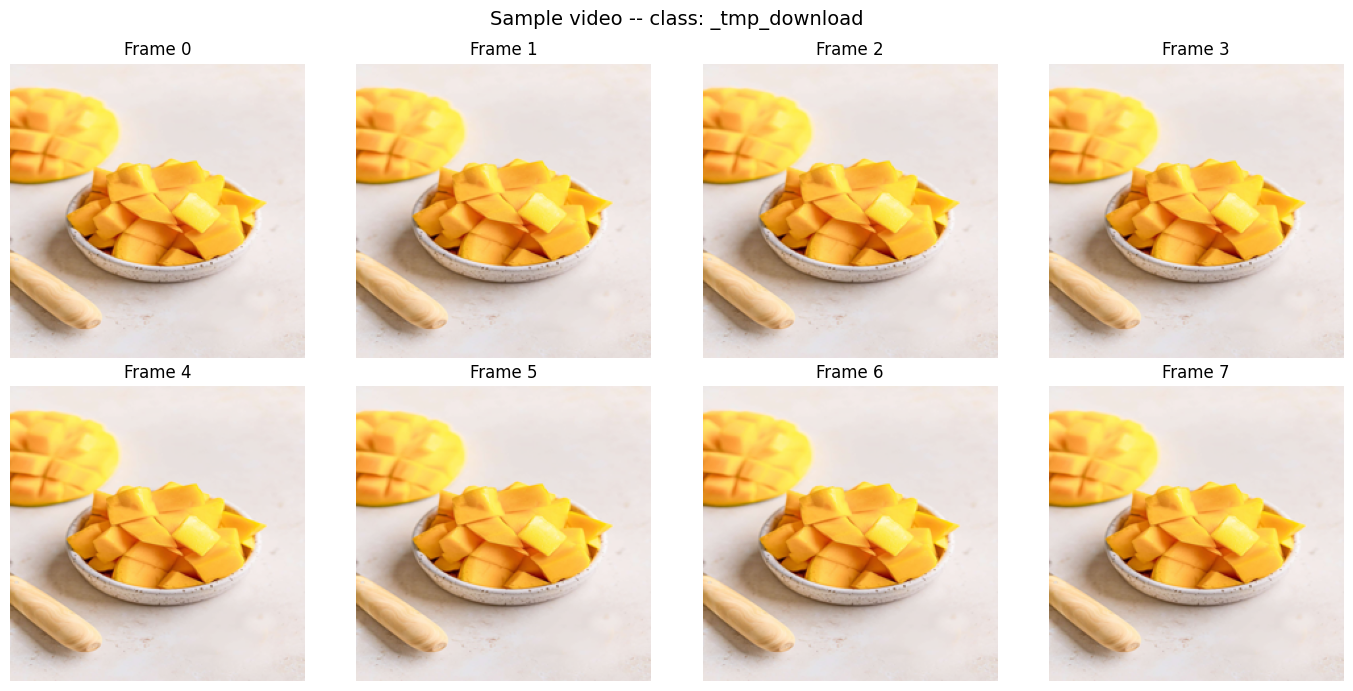

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from vit_video.data.dataset import VideoDataset

preview_ds = VideoDataset(root=FRAMES_DIR, frames_per_video=8, img_size=224, augment=False)
print(f'Dataset: {len(preview_ds)} videos, classes: {preview_ds.classes}')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
video_tensor, label = preview_ds[0]
for i, ax in enumerate(axes.flat):
    frame = video_tensor[i].permute(1, 2, 0).numpy()
    frame = frame * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    ax.imshow(frame.clip(0, 1))
    ax.set_title(f'Frame {i}')
    ax.axis('off')
fig.suptitle(f'Sample video -- class: {preview_ds.classes[label]}', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Train/Val/Test Split

In [ ]:
from vit_video.data.splits import ensure_split_manifest

manifest_path = ensure_split_manifest(
    frames_root=FRAMES_DIR,
    manifest_path=DATASET_DIR / 'video_split_manifest.json',
    train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
    seed=42,
)
print(f'Split manifest: {manifest_path}')

[Split] Wrote train/val/test manifest: /content/moderation-service/src/vit_video/food_data/video_split_manifest.json
Split manifest: /content/moderation-service/src/vit_video/food_data/video_split_manifest.json


## 9. Training

Resumes from Drive checkpoint if available. Syncs to Drive after each best epoch.

In [ ]:
import argparse, shutil, os, sys

# Ensure the source directory is in sys.path in case of kernel reset
REPO_DIR = '/content/moderation-service'
SRC_DIR = os.path.join(REPO_DIR, 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Now that the path is set, we can safely import from vit_video
from vit_video.train import main as train_main

MODEL_PATH = PACKAGE_ROOT / 'models' / 'best_food_classifier.pth'
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Resume from Drive if available
resume_path = ''
if DRIVE_CHECKPOINT_PATH and os.path.exists(DRIVE_CHECKPOINT_PATH):
    try:
        shutil.copy2(DRIVE_CHECKPOINT_PATH, str(MODEL_PATH))
        resume_path = str(MODEL_PATH)
        print(f'Resuming from Drive: {DRIVE_CHECKPOINT_PATH}')
    except Exception as e:
        print(f'Could not copy checkpoint: {e}')
        resume_path = ''
else:
    print('Starting training from scratch')

train_args = argparse.Namespace(
    dataset_dir=str(FRAMES_DIR),
    epochs=10,
    batch_size=8,
    lr=3e-5,
    weight_decay=1e-3,
    max_grad_norm=1.0,
    dropout=0.4,
    num_frames=8,
    img_size=224,
    disable_augmentation=False,
    class_weighting=True,
    min_samples_per_class=20,
    temporal_pool='lstm',
    norm_mean='0.485,0.456,0.406',
    norm_std='0.229,0.224,0.225',
    hparam_search_epochs=0,
    lr_candidates='5e-6,1e-5,3e-5,5e-5,1e-4',
    num_workers=2,
    patience=7,
    min_delta=5e-5,
    backbone='auto',
    output_model=str(MODEL_PATH),
    resume_from=resume_path,
    drive_checkpoint_dir=DRIVE_CHECKPOINT_DIR,
    split_manifest=str(manifest_path),
    no_auto_split_manifest=True,
    train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
    split_seed=42,
)

train_main(train_args)

if MODEL_PATH.exists() and DRIVE_CHECKPOINT_PATH:
    shutil.copy2(str(MODEL_PATH), DRIVE_CHECKPOINT_PATH)
    print(f'Final checkpoint synced to Drive')

model_path = str(MODEL_PATH)
print(f'\nSaved model: {model_path}')

ModuleNotFoundError: No module named 'vit_video'

### Training History

In [ ]:
import json

history_file = MODEL_PATH.with_name(MODEL_PATH.stem + '_history.json')
if history_file.exists():
    history = json.loads(history_file.read_text())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train', marker='o', markersize=4)
    ax1.plot(history['val_loss'], label='Val', marker='s', markersize=4)
    ax1.set(xlabel='Epoch', ylabel='Loss', title='Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history['train_acc'], label='Train', marker='o', markersize=4)
    ax2.plot(history['val_acc'], label='Val', marker='s', markersize=4)
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f'No history file at {history_file}')

NameError: name 'MODEL_PATH' is not defined

## 10. Evaluation on Test Split

In [ ]:
from vit_video.test import build_test_loader, evaluate, print_results, save_results
from vit_video.utils.model_utils import load_model_from_checkpoint

test_loader, classes, _ = build_test_loader(
    dataset_root=str(FRAMES_DIR), batch_size=4, num_frames=8, num_workers=2,
    split_manifest=str(manifest_path),
)
NUM_CLASSES = len(classes)
model = load_model_from_checkpoint(model_path, num_classes=NUM_CLASSES, device=device)
results = evaluate(model, test_loader, device, classes)
print_results(results)
save_results(results, PACKAGE_ROOT / 'results')

In [ ]:
import seaborn as sns
import numpy as np

cm = np.array(results['confusion_matrix'])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set(xlabel='Predicted', ylabel='Actual', title=f'Confusion Matrix ({NUM_CLASSES} classes)')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(f'\nAccuracy:  {results["accuracy"]:.4f}')
print(f'Precision: {results["precision_macro"]:.4f}')
print(f'Recall:    {results["recall_macro"]:.4f}')
print(f'F1:        {results["f1_macro"]:.4f}')

## 11. Health-Label Rollup

In [ ]:
from sklearn.metrics import confusion_matrix as sk_cm, classification_report

preds = results['predictions']
truths = results['ground_truth']

health_preds = [HEALTH_LABELS.get(classes[p], '?') for p in preds]
health_truths = [HEALTH_LABELS.get(classes[t], '?') for t in truths]

health_correct = sum(p == t for p, t in zip(health_preds, health_truths))
health_acc = health_correct / len(health_preds) if health_preds else 0
print(f'Health-level accuracy: {health_acc:.2%} ({health_correct}/{len(health_preds)})')
print()

health_labels = ['healthy', 'unhealthy', 'not_food']
h_cm = sk_cm(health_truths, health_preds, labels=health_labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(h_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=health_labels, yticklabels=health_labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Health-Level Confusion (acc={health_acc:.1%})')
plt.tight_layout()
plt.show()

print(classification_report(health_truths, health_preds, labels=health_labels, zero_division=0))

## 12. Inference Demo

In [ ]:
import torch
from PIL import Image
from vit_video.utils.data_utils import build_transform
import time

transform = build_transform(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
test_dirs = ['fruits', 'burgers', 'not_food']
model.eval()

fig, axes = plt.subplots(1, len(test_dirs), figsize=(5 * len(test_dirs), 5))
for ax, cls_name in zip(axes, test_dirs):
    sample = sorted(FRAMES_DIR.glob(f'{cls_name}/*.jpg'))[:1]
    if not sample:
        ax.set_title(f'{cls_name}: no images'); ax.axis('off'); continue
    img = Image.open(sample[0]).convert('RGB').resize((224, 224))
    video_tensor = torch.stack([transform(img)] * 8).unsqueeze(0).to(device)
    with torch.no_grad():
        start = time.perf_counter()
        outputs = model(video_tensor)
        ms = (time.perf_counter() - start) * 1000.0
        probs = torch.softmax(outputs, dim=1)
        idx = torch.argmax(probs, dim=1).item()
    pred_class = classes[idx]
    health = HEALTH_LABELS.get(pred_class, '?')
    ax.imshow(img)
    ax.set_title(f'{pred_class} ({probs[0][idx]:.0%})\n[{health}] {ms:.0f}ms')
    ax.axis('off')
plt.suptitle('Inference Demo', fontsize=14); plt.tight_layout(); plt.show()

## 13. Export to Mobile Formats

In [ ]:
# Install TFJS export deps once (Colab). Comment out after first run.
# !pip install -q tensorflowjs onnx onnx-tf ai_edge_torch

export_script = str(PACKAGE_ROOT / 'export_mobile.py')
export_dir = PACKAGE_ROOT / 'exported_models'
results_file = PACKAGE_ROOT / 'results' / 'test_results.json'

# 'tfjs' requires mobilevit_xxs backbone for reasonable browser size (~1.5 MB uint8)
# ViT-B/16 would produce a ~330 MB bundle -- not web-deployable.
EXPORT_FORMATS = ['torchscript', 'onnx', 'tflite', 'tfjs']  # add 'coreml' on macOS
QUANTIZE = True  # float16 for tflite, uint8 for tfjs

cmd = [sys.executable, export_script,
       '--model', str(model_path), '--output-dir', str(export_dir),
       '--format', *EXPORT_FORMATS,
       '--num-classes', str(NUM_CLASSES),
       '--classes', ','.join(classes),
       '--eval-results', str(results_file)]
if QUANTIZE:
    cmd.append('--quantize')
subprocess.run(cmd, check=False)

print('
Exported files:')
for f in sorted(export_dir.rglob('*')):
    if f.is_file():
        rel = f.relative_to(export_dir)
        print(f'  {str(rel):50s} {f.stat().st_size / 1024 / 1024:>7.2f} MB')

## 14. Upload Model to HuggingFace

In [ ]:
# Set SKIP_MODEL_UPLOAD = False to upload trained model to HF
SKIP_MODEL_UPLOAD = False

if not SKIP_MODEL_UPLOAD and HF_TOKEN:
    HF_MODEL_REPO = 'maia2000/food-classifier-vitb16'
    upload_script = str(PACKAGE_ROOT / 'upload_hf.py')
    cmd = [sys.executable, upload_script,
           '--repo-id', HF_MODEL_REPO,
           '--export-dir', str(export_dir)]
    subprocess.run(cmd, check=False)
    print(f'Model uploaded: https://huggingface.co/{HF_MODEL_REPO}')
elif not HF_TOKEN:
    print('[SKIP] No HF_TOKEN -- add it to Colab Secrets to enable upload')
else:
    print('[SKIP] Model upload')

## Model Summary

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
backbone = getattr(model, 'model_name', 'auto')
temporal = getattr(model, 'temporal_pool', 'lstm')

print('Model Summary')
print(f'  Architecture:       MobileViTModel + BiLSTM')
print(f'  Backbone:           {backbone}')
print(f'  Temporal pooling:   {temporal}')
print(f'  Total parameters:   {total_params:,}')
print(f'  Trainable params:   {trainable:,}')
print(f'  Input shape:        (B, 8, 3, 224, 224)')
print(f'  Output:             (B, {NUM_CLASSES})')
print(f'  Classes:            {classes}')
print(f'  Device:             {device}')